# Julia basics
A quick reminder for future reference.

In [45]:
# It's very similar to python in many ways.
✨ = 3.14159265
pi_sq = ✨^2
println("Happy Pi-day! This is how much of pi I know by heart: $✨.\nAlso, the square of that is $(pi_sq), isn't that neat?")

Happy Pi-day! This is how much of pi I know by heart: 3.14159265.
Also, the square of that is 9.869604378534024, isn't that neat?


In [46]:
# type conversion & parsing strings:
println(convert(Int64, 3.0))
parse(Int64, "4")

3


4

Tuples and lists look the same as in Python (except we have 1-based indexing instead of 0). 
Dicts are slightly different:

In [47]:
# dicts:
my_dict = Dict("Claudio" => "Brownies", "Emil" => "Eierschecke")
my_dict["Laura"] = "Eierkuchen"
my_dict

Dict{String, String} with 3 entries:
  "Laura"   => "Eierkuchen"
  "Claudio" => "Brownies"
  "Emil"    => "Eierschecke"

Let's modify the dict with pop!() (which works on other data types to)

In [48]:
pop!(my_dict, "Laura")

"Eierkuchen"

In [49]:
my_dict

Dict{String, String} with 2 entries:
  "Claudio" => "Brownies"
  "Emil"    => "Eierschecke"

Check out this super basic loop - in Julia we have to finish it with an end statement! (same thing goes for if - else statements)

In [50]:
data = rand(100, 100)
sum = 0
for d in data
    sum += d
end
println(sum)

4975.769319194212


Julia is very chill about how to phrase the loop iterator, you can say for i in 1:m, for i = 1:m, ...

In [51]:
m, n = 5, 5
A = zeros(m,n) # allocating this first should be nice & faster

for i = 1:m, j = 1:n 
    A[i, j] = i*j 
end
A

5×5 Matrix{Float64}:
 1.0   2.0   3.0   4.0   5.0
 2.0   4.0   6.0   8.0  10.0
 3.0   6.0   9.0  12.0  15.0
 4.0   8.0  12.0  16.0  20.0
 5.0  10.0  15.0  20.0  25.0

Julia also has list comprehensions like Python!

In [52]:
B = [i*j for i in 1:n, j in 1:m]

5×5 Matrix{Int64}:
 1   2   3   4   5
 2   4   6   8  10
 3   6   9  12  15
 4   8  12  16  20
 5  10  15  20  25

Also this neat little shortcut for if-else statements: 

(condition) ? this if True : that if False.

In [53]:
x, y = 4, 5
(x>y) ? x : y
#... not sure if I'll ever actually use that though.

5

Now, functions:

In [54]:
# extremely basic function definition:
function f1(x)
    x^2
end

f1 (generic function with 1 method)

In [55]:
f1(42)

1764

Or, for anonymous/lambda functions:

In [56]:
f2 = name -> println("Hi $name !") # lambda function definition
f2("Theodore")

Hi Theodore !


Broadcasting: (f(A) applies f to matrix A, f.(A) applies f to elements of matrix A -> broadcast)

In [ ]:
f(x) = x^2 # you can also define simple functions as oneliners like this!
A = rand(0:5,3,3) # 3x3 matrix with entries between 0 and 5
println(f(A))
println(f.(A))

[14 16 12; 20 36 24; 8 11 10]
[0 9 4; 16 16 16; 1 4 0]


In [73]:
A' # this is the transpose of A!

3×3 adjoint(::Matrix{Int64}) with eltype Int64:
 0  4  1
 3  4  2
 2  4  0

In [ ]:
A'A # this does the transpose multiplication automatically!

3×3 Matrix{Int64}:
 17  18  16
 18  29  22
 16  22  20

In [ ]:
b = rand(1:3, 3)
x = A\b # backslash solves Ax = b isn't this neat?????? 
println(x)

# if it's overdetermined, we get the least squares:
Atall = A[:, 1:2] # keep only first 2 columns of Atall
xlsq = Atall\b

[-0.20000000000000007, 1.1, -0.15000000000000005]


2-element Vector{Float64}:
 -0.26035502958579887
  1.0236686390532543

Mutating functions: end with ! (sort(v) returns a sorted copy without changing original v, vs sort!(v) sorts vector v itself)

In [58]:
v = rand(5) # random vector
println(v)
println(sort(v)) # non-mutating sort
println(v) # same old v!
println(sort!(v)) # now mutating sort!
println(v) # v is changed 🤯

[0.05510402717354168, 0.05729953646897945, 0.07805175193070946, 0.6447290606957757, 0.737197379655965]
[0.05510402717354168, 0.05729953646897945, 0.07805175193070946, 0.6447290606957757, 0.737197379655965]
[0.05510402717354168, 0.05729953646897945, 0.07805175193070946, 0.6447290606957757, 0.737197379655965]
[0.05510402717354168, 0.05729953646897945, 0.07805175193070946, 0.6447290606957757, 0.737197379655965]
[0.05510402717354168, 0.05729953646897945, 0.07805175193070946, 0.6447290606957757, 0.737197379655965]


Installing Packages (can also be done via built-in package manager of the Julia REPL - just open it and type `]` to enter the package manager! You can add/remove packages, check the `status`of the installed packages, etc)

In [59]:
# installing packages
using Pkg # this is used for installing new packages
#Pkg.add("Graphs") # installing Graphs package
#Pkg.add("Colors") # installing Colors package
#Pkg.add("Plots") # installing Colors package
#Pkg.add("PlotlyJS") # installing Colors package
# this package might be useful!

In [60]:
using Graphs # importing the Graphs.jl package
using Colors 
using Plots 

Let's do some basic plotting!

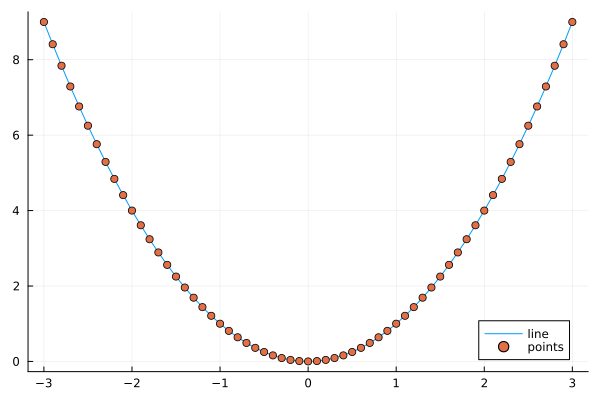

In [61]:
# also, for quickly making simple arrays we can do this
# very similar to pythons range()/ numpy.arange
# just slightly different order
x = -3:0.1:3 # start:step:stop
f(x) = x^2
y = f.(x) # the square from above, applied element-wise

# loading the GR backend 
gr()
plot(x, y, label="line")
scatter!(x, y, label="points") # the ! is important to add the scatter plot
# without it, the scatter would override the line plot

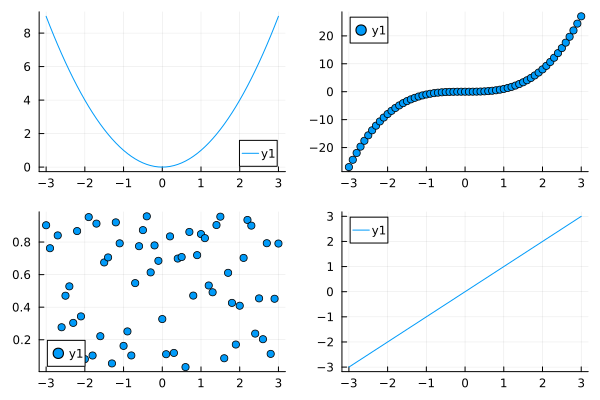

In [62]:
p1 = plot(x, y)
p2 = scatter(x, x.^3)
p3 = scatter(x, rand(length(x)))
p4 = plot(x, x)
plot(p1, p2, p3, p4, layout=(2,2))

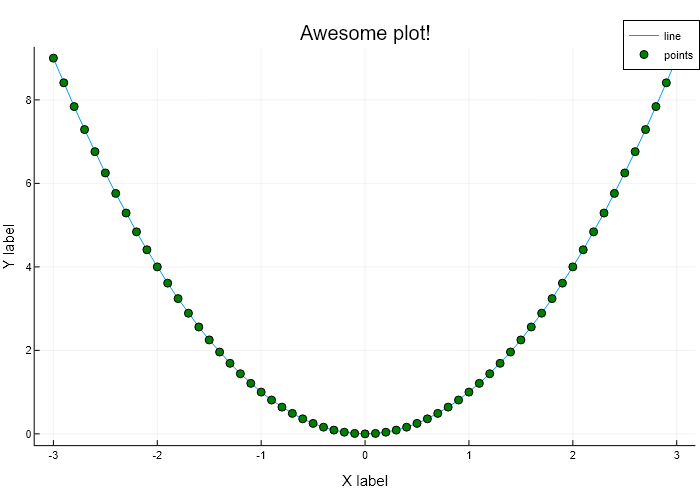

In [63]:
# let's try another backend:
# looks the same, but a little more interactive!
plotlyjs()
plot(x, y, label="line")
scatter!(x, y, label="points", color="green")
xlabel!("X label")
ylabel!("Y label")
title!("Awesome plot!")

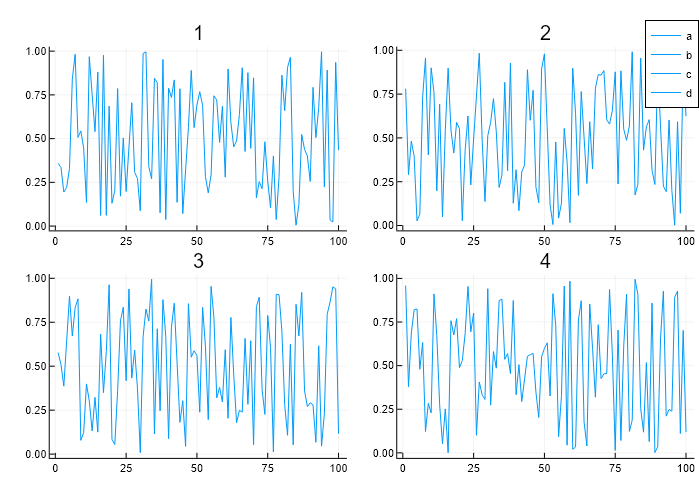

In [64]:
plot(rand(100,4); layout = 4, label=["a" "b" "c" "d"], title=["1" "2" "3" "4"])

Ok, let's quickly cover structs as well ig...

here's an immutable struct:

In [65]:
# this is an immutable struct, we can't change attributes after creation!
struct coolObject
    coolness
    awesomeness
    description
end

test = coolObject(4, 5, "box cutter")
test.awesomeness

5

aaaand here's a mutable struct:

In [66]:
mutable struct radObject
    radness::Int128
    awesomeness::Int128
    description::String

    # constructor
    function radObject(radness, awesomeness)
        new(radness, awesomeness, "Too lazy to describe it")
    end
end

test = radObject(7, 87, "Pancake")
test2 = radObject(10, 10)

radObject(10, 10, "Too lazy to describe it")

In [67]:
test.radness += 1000
test

radObject(1007, 87, "Pancake")

And one funky little function with the struct:

In [68]:
function 🤯(obj::radObject)
    obj.radness += 1000
end

🤯 (generic function with 1 method)

In [69]:
🤯(test)
test

radObject(2007, 87, "Pancake")

Some Linear Algebra etc


In [84]:
b = rand(1:3, 3)
x = A\b # backslash solves Ax = b isn't this neat?????? 
println(x)

# if it's overdetermined, we get the least squares:
Atall = A[:, 1:2] # keep only first 2 columns of Atall
xlsq = Atall\b

[-0.8, 0.9, 0.14999999999999997]


2-element Vector{Float64}:
 -0.7396449704142013
  0.9763313609467456

In [90]:
using LinearAlgebra

Facotrization:

In [109]:
# LU-factorization:
A = randn(3,3) # random normal 3x3 matrix 
display(A)
display(tr(A))
display(det(A))
display(inv(A))
display(diag(A))

l, u, p = lu(A)

3×3 Matrix{Float64}:
  0.84984    1.58858    0.0901705
 -0.964151   1.00836   -1.88284
 -0.325136  -0.808931   0.599735

2.457939022556327

1.2105125693401984

3×3 Matrix{Float64}:
 -0.758637  -0.847299  -2.546
  0.983398   0.445263   1.25003
  0.915139   0.141229   1.97319

3-element Vector{Float64}:
 0.8498397366034757
 1.0083641882510639
 0.5997350977017875

LU{Float64, Matrix{Float64}, Vector{Int64}}
L factor:
3×3 Matrix{Float64}:
  1.0        0.0       0.0
 -0.881438   1.0       0.0
  0.337225  -0.463786  1.0
U factor:
3×3 Matrix{Float64}:
 -0.964151  1.00836  -1.88284
  0.0       2.47739  -1.56944
  0.0       0.0       0.506793

In [104]:
# eigendecomposition
Asym = A+A'
eigva = eigvals(Asym)
eigve = eigvecs(Asym)
display(eigva)
display(eigve)

3-element Vector{Float64}:
 -5.368546526306006
 -0.8067220866123994
  2.634305927048821

3×3 Matrix{Float64}:
 0.863659   -0.142884   0.483402
 0.502354    0.164766  -0.848818
 0.0416347   0.975929   0.21408

In [107]:
# OR we use
eigs = eigen(Asym)

Eigen{Float64, Float64, Matrix{Float64}, Vector{Float64}}
values:
3-element Vector{Float64}:
 -5.368546526306004
 -0.8067220866123939
  2.6343059270488207
vectors:
3×3 Matrix{Float64}:
 0.863659   -0.142884   0.483402
 0.502354    0.164766  -0.848818
 0.0416347   0.975929   0.21408

In [108]:
display(eigs.values)
display(eigs.vectors)

3-element Vector{Float64}:
 -5.368546526306004
 -0.8067220866123939
  2.6343059270488207

3×3 Matrix{Float64}:
 0.863659   -0.142884   0.483402
 0.502354    0.164766  -0.848818
 0.0416347   0.975929   0.21408

There are also special matrix structures (Diagonal, Triangular, Hermitian, ...) but let's skip over that for now. Just now that explicitly declaring a special matrix like A = Symmetric(Asym) might make things neater in terms of dealing with floating-point errors and also make certain operations way faster.

In [ ]:
A = randn(3000, 3000)
Asym = A + A'

@time eigvals(Asym)
@time eigvals(Symmetric(Asym))

In [ ]:
Asym_noisy = copy(Asym);
Asym_noisy = 5eps()*randn(3000,3000) # some random noise
@time eigvals(Asym_noisy)
@time eigvals(Symmetric(Asym_noisy))

2.220446049250313e-16

  0.155069 seconds (134.61 k allocations: 14.982 MiB, 5.23% gc time, 62.20% compilation time)


1000-element Vector{Float64}:
 -87.97875420397128
 -87.70444158300188
 -86.97398637059887
 -85.88116444036307
 -85.64905044143174
 -85.33969966695213
 -84.22786557693003
 -84.08328974305913
 -83.94851907412804
 -83.48672030179634
   ⋮
  84.55474038228749
  84.90470162346551
  85.39671194028824
  86.06913048137113
  86.33531296972804
  86.79011259397413
  87.19261680006117
  87.97703266141247
  89.27032156842284